In [2]:
# ============================
# Install Libraries
# ============================

!pip install pandas scikit-learn

# ============================
# Import Libraries
# ============================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

# ============================
# Load Dataset
# ============================

url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt"

columns = list(range(43))

data = pd.read_csv(url, names=columns)

print("Dataset Shape:", data.shape)

# ============================
# Separate Features and Label
# ============================

X = data.iloc[:, :-2]   # Features
y = data.iloc[:, -2]    # Attack label

# ============================
# Encode Categorical Features
# ============================

for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# ============================
# Train Test Split
# ============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================
# Train Model
# ============================

model = RandomForestClassifier(n_estimators=100)

model.fit(X_train, y_train)

# ============================
# Model Evaluation
# ============================

pred = model.predict(X_test)

print(classification_report(y_test, pred))

# ============================
# Agentic AI Decision Engine
# ============================

def security_agent(network_data):

    prediction = model.predict([network_data])[0]

    attack_type = label_encoder.inverse_transform([prediction])[0]

    if attack_type == "normal":
        action = "System Safe - Continue Monitoring"

    elif attack_type in ["neptune","smurf","back"]:
        action = "⚠️ DoS Attack Detected → Block Source IP"

    elif attack_type in ["satan","ipsweep"]:
        action = "⚠️ Network Scan Detected → Alert Admin"

    else:
        action = "⚠️ Suspicious Activity → Isolate Device"

    return attack_type, action


# ============================
# Test Agent
# ============================

sample = X_test.iloc[0].values

threat, response = security_agent(sample)

print("Threat Type:", threat)
print("Agent Response:", response)

Dataset Shape: (125973, 43)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       185
           1       1.00      0.33      0.50         9
           3       1.00      0.91      0.95        11
           4       1.00      1.00      1.00         1
           5       0.99      0.99      0.99       733
           6       0.00      0.00      0.00         3
           9       1.00      1.00      1.00      8228
          10       0.98      0.99      0.99       313
          11       1.00      1.00      1.00     13422
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      0.93      0.96        43
          15       1.00      0.99      1.00       573
          16       0.00      0.00      0.00         1
          17       1.00      0.99      0.99       738
          18       1.00      1.00      1.00       534
          19       0.00      0.00      0.00         1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Dataset Shape: (125973, 43)
   0    1         2   3    4     5   6   7   8   9   ...    33    34    35  \
0   0  tcp  ftp_data  SF  491     0   0   0   0   0  ...  0.17  0.03  0.17   
1   0  udp     other  SF  146     0   0   0   0   0  ...  0.00  0.60  0.88   
2   0  tcp   private  S0    0     0   0   0   0   0  ...  0.10  0.05  0.00   
3   0  tcp      http  SF  232  8153   0   0   0   0  ...  1.00  0.00  0.03   
4   0  tcp      http  SF  199   420   0   0   0   0  ...  1.00  0.00  0.00   

     36    37    38    39    40       41  42  
0  0.00  0.00  0.00  0.05  0.00   normal  20  
1  0.00  0.00  0.00  0.00  0.00   normal  15  
2  0.00  1.00  1.00  0.00  0.00  neptune  19  
3  0.04  0.03  0.01  0.00  0.01   normal  21  
4  0.00  0.00  0.00  0.00  0.00   normal  21  

[5 rows x 43 columns]


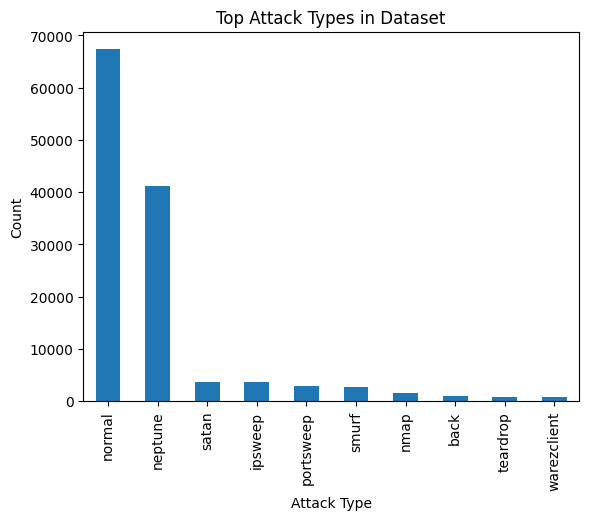


Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       185
           1       1.00      0.33      0.50         9
           3       1.00      0.91      0.95        11
           4       1.00      1.00      1.00         1
           5       0.99      0.99      0.99       733
           6       0.00      0.00      0.00         3
           9       1.00      1.00      1.00      8228
          10       0.98      0.99      0.99       313
          11       1.00      1.00      1.00     13422
          12       0.00      0.00      0.00         1
          13       1.00      1.00      1.00         1
          14       1.00      0.93      0.96        43
          15       1.00      0.99      1.00       573
          16       0.00      0.00      0.00         1
          17       1.00      0.99      0.99       738
          18       1.00      1.00      1.00       534
          19       0.00      0.00      0.00         1
   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


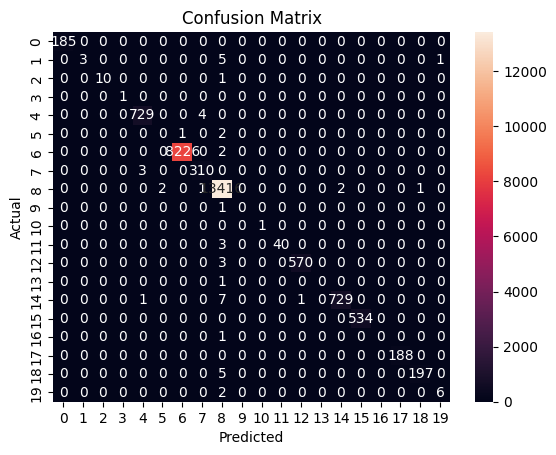

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


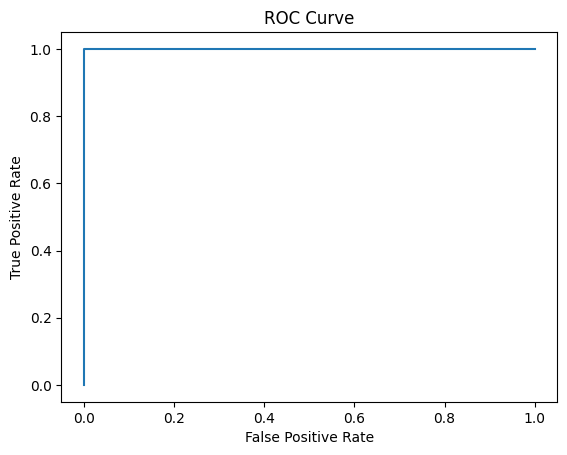

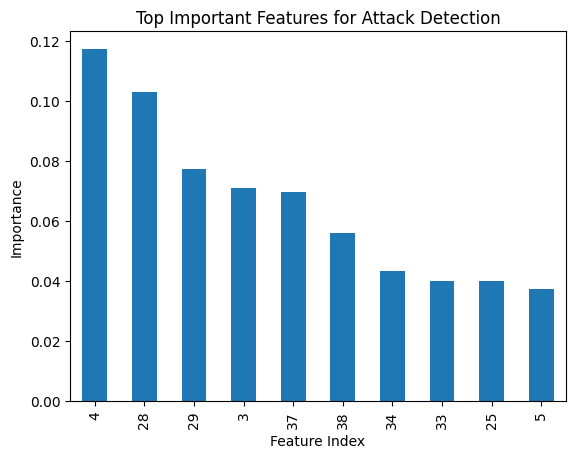


Agentic AI Result
Threat Type: normal
Agent Response: System Safe - Continue Monitoring


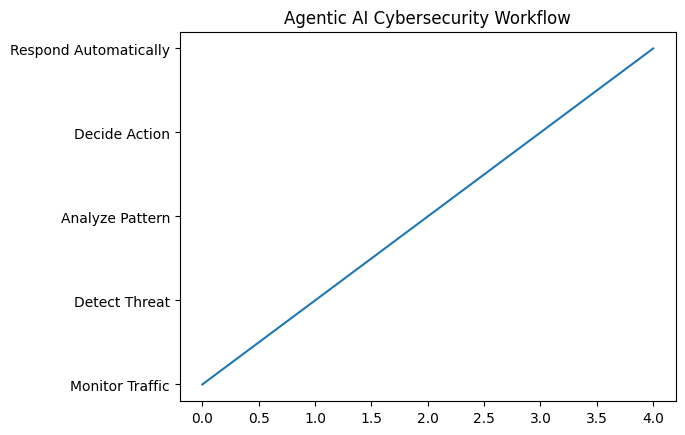

In [3]:
# ==============================
# AUTOSEC AGENT
# Agentic AI Cybersecurity System
# ==============================

# Install libraries
!pip install pandas scikit-learn matplotlib seaborn

# ==============================
# Import Libraries
# ==============================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelEncoder

# ==============================
# Load Dataset
# ==============================

url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt"

columns = list(range(43))

data = pd.read_csv(url, names=columns)

print("Dataset Shape:", data.shape)

print(data.head())

# ==============================
# Attack Distribution Graph
# ==============================

attack_counts = data[41].value_counts().head(10)

plt.figure()

attack_counts.plot(kind='bar')

plt.title("Top Attack Types in Dataset")

plt.xlabel("Attack Type")

plt.ylabel("Count")

plt.show()

# ==============================
# Feature and Label Separation
# ==============================

X = data.iloc[:, :-2]

y = data.iloc[:, -2]

# ==============================
# Encode Categorical Features
# ==============================

for col in X.columns:

    if X[col].dtype == 'object':

        le = LabelEncoder()

        X[col] = le.fit_transform(X[col])

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

# ==============================
# Train Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==============================
# Train Random Forest Model
# ==============================

model = RandomForestClassifier(n_estimators=100)

model.fit(X_train, y_train)

# ==============================
# Predictions
# ==============================

pred = model.predict(X_test)

# ==============================
# Classification Report
# ==============================

print("\nClassification Report\n")

print(classification_report(y_test, pred))

# ==============================
# Confusion Matrix
# ==============================

cm = confusion_matrix(y_test, pred)

plt.figure()

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ==============================
# ROC Curve
# ==============================

probs = model.predict_proba(X_test)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(model.classes_)):

    fpr[i], tpr[i], _ = roc_curve(y_test == i, probs[:, i])

    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()

plt.plot(fpr[0], tpr[0])

plt.title("ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.show()

# ==============================
# Feature Importance Graph
# ==============================

importance = model.feature_importances_

feat_importance = pd.Series(importance)

top_features = feat_importance.nlargest(10)

plt.figure()

top_features.plot(kind='bar')

plt.title("Top Important Features for Attack Detection")

plt.xlabel("Feature Index")

plt.ylabel("Importance")

plt.show()

# ==============================
# Agentic AI Decision Engine
# ==============================

def security_agent(network_data):

    prediction = model.predict([network_data])[0]

    attack_type = label_encoder.inverse_transform([prediction])[0]

    if attack_type == "normal":

        action = "System Safe - Continue Monitoring"

    elif attack_type in ["neptune","smurf","back"]:

        action = "⚠️ DoS Attack Detected → Block Source IP"

    elif attack_type in ["satan","ipsweep"]:

        action = "⚠️ Network Scan Detected → Alert Admin"

    else:

        action = "⚠️ Suspicious Activity → Isolate Device"

    return attack_type, action


# ==============================
# Test the AI Security Agent
# ==============================

sample = X_test.iloc[0].values

threat, response = security_agent(sample)

print("\nAgentic AI Result")

print("Threat Type:", threat)

print("Agent Response:", response)

# ==============================
# Agentic AI Workflow Graph
# ==============================

steps = [
    "Monitor Traffic",
    "Detect Threat",
    "Analyze Pattern",
    "Decide Action",
    "Respond Automatically"
]

plt.figure()

plt.plot(steps)

plt.title("Agentic AI Cybersecurity Workflow")

plt.show()